# Automated Document Scanner & Enhancer

In [54]:
import numpy as np
import cv2

# cap = cv2.VideoCapture(0)  #use this to get the doc from the webcam
# ret,frame = cap.read()
# img = frame.copy()
# cap.release()


img = cv2.resize(cv2.imread("..\\fol\\doc.jpeg"),(0,0),fx=0.5,fy=0.5)
hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

# Using inRange to get the mask
#  Define range of white/light colors in HSV (Paper reflects light, so high Value)
# Hue: 0-180 (any color), Saturation: 0-50 (not very colorful), Value: 100-255 (bright)

lower_paper = np.array([0, 0, 80])
upper_paper = np.array([180, 50, 255])
mask = cv2.inRange(hsv, lower_paper, upper_paper)


# # Clean up the mask using Morphological operations (We will learn this in Phase 2, 
# # but here is a quick preview to remove tiny noise dots)
# kernel = np.ones((7,7), np.uint8)
# mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
# mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)


# Using and to get the foreground only
foreground = cv2.bitwise_and(
    img,
    img,
    mask = mask
)

cv2.imshow("Foreground",foreground)


cv2.namedWindow('image')

points = []

def mouse_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        cv2.circle(img, (x, y), 10, (0, 0, 255), 3)
        cv2.imshow("image", img)
        points.append((x, y))


def Selectpoints():
    cv2.setMouseCallback('image', mouse_event)

    cv2.imshow('image', img)

    cv2.waitKey(0)
    cv2.destroyWindow('image')

    return points

srcpoints = Selectpoints()
if len(points) != 4:
    raise ValueError("Please select exactly 4 points")

dstpoints = np.float32(
    [[0,0],[img.shape[1],0],[img.shape[1],img.shape[0]],[0,img.shape[0]]]
)

M = cv2.getPerspectiveTransform(
    np.float32(srcpoints),
    dstpoints
)

warped = cv2.warpPerspective(
    foreground,
    M,
    (img.shape[1],img.shape[0])
)
cv2.imshow('warped',warped)

gray_doc = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)
enhanced_doc = clahe.apply(gray_doc)

cv2.imshow('enhanced_doc',enhanced_doc)

cv2.imshow('mask',mask)
cv2.waitKey(0)
cv2.destroyAllWindows()



# Metal Surface Detection using OpenCV

Solution Strategy:

    Convert the metal surface image to grayscale.
    Apply Gaussian Blur to remove high-frequency sensor noise (so we don't detect noise as scratches).
    Apply Canny Edge Detection to find all sharp intensity changes (scratches).
    Use Morphological Closing (MORPH_CLOSE) to connect broken segments of the same scratch into a single, continuous line.
    Use Morphological Opening (MORPH_OPEN) to remove tiny, isolated specks of dust that the Canny detector mistakenly flagged.

In [67]:
import cv2
import numpy as np

# img = cv2.imread('..\\fol\\raw_metal.jpg')

img = cv2.imread('..\\fol\\metal_surface.jpg')


grayed = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# Applying gaussian blur 
blurred  = cv2.GaussianBlur(grayed,(5,5),0)
cv2.imshow("Blurred",blurred)

# Canny edge detection
edges  = cv2.Canny(
    img,
    100,
    200,
    apertureSize=3
)
cv2.imshow("Edges",edges)

# edgeed =cv2.morphologyEx(
#     edges,
#     cv2.MORPH_CLOSE,
#     np.ones((3,3),np.uint8)
# )
# edged = cv2.morphologyEx(
#     edgeed,
#     cv2.MORPH_OPEN,
#     np.ones((3,3),np.uint8)
# )
# cv2.imshow("Edged",edged)

# Contours
contours,hierarchy = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

for cnt in contours:
    per = cv2.arcLength(cnt,True)
    vertices = cv2.approxPolyDP(cnt,0.02*per,True)
    if len(vertices) == 4:
        cv2.drawContours(
            img,
            [vertices],
            0,
            (0,255,0),
            3
        )
cv2.imshow("Contour",img)
cv2.imshow("raw",img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [71]:
import cv2
import numpy as np
import math

# 1. Create a Synthetic Conveyor Belt Image
# (In reality, you would use cv2.imread() on a photo from your camera)
img = np.ones((400, 600, 3), dtype=np.uint8) * 50  # Dark gray background (conveyor)

# Draw a circular washer (white)
cv2.circle(img, (150, 200), 60, (255, 255, 255), -1)
# Draw a rectangular bracket (white), rotated at an angle
rect_center = (450, 200)
rect_size = (120, 60)
rect_angle = 35
box = cv2.boxPoints((rect_center, rect_size, rect_angle))
box = np.intp(box)
cv2.drawContours(img, [box], 0, (255, 255, 255), -1)
# Add some "noise" (tiny white specks)
cv2.circle(img, (50, 50), 3, (255, 255, 255), -1)
cv2.circle(img, (550, 350), 4, (255, 255, 255), -1)

# 2. Preprocessing: Grayscale & Thresholding
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Otsu's thresholding automatically finds the best cutoff for the white parts
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Find Contours
# ⭐ RETR_EXTERNAL gets only the outer boundaries. CHAIN_APPROX_SIMPLE saves RAM.
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

robot_commands = []

# 4. Analyze Each Contour
for cnt in contours:
    area = cv2.contourArea(cnt)
    
    # Filter out noise (dust specks)
    if area < 500:
        continue

    # --- SHAPE CLASSIFICATION ---
    # Find the minimum enclosing circle
    (cx, cy), radius = cv2.minEnclosingCircle(cnt)
    circle_area = math.pi * (radius ** 2)
    
    # Circularity = Object Area / Enclosing Circle Area. 
    # A perfect circle is 1.0. A square is ~0.78.
    circularity = area / circle_area 
    
    part_type = "Unknown"
    gripper_rotation = 0.0

    if circularity > 0.85:
        part_type = "WASHER (Circular)"
        # For a circle, rotation doesn't matter, set to 0
        gripper_rotation = 0.0 
    else:
        part_type = "BRACKET (Rectangular)"
        # --- ROBOTIC PICK-AND-PLACE DATA ---
        # ⭐ minAreaRect gives us the exact orientation of the part
        rect = cv2.minAreaRect(cnt)
        center, size, angle = rect
        
        # OpenCV's minAreaRect angle can be tricky. 
        # We adjust it so the robot knows exactly how to align its gripper.
        if size[0] < size[1]:
            gripper_rotation = angle + 90
        else:
            gripper_rotation = angle
            
        # Draw the rotated bounding box on the image for visualization
        box = cv2.boxPoints(rect)
        box = np.intp(box)
        cv2.drawContours(img, [box], 0, (0, 255, 0), 2) # Green box

    # --- CALCULATE TRUE CENTROID (Center of Mass) ---
    # ⭐ Moments give a more accurate center for irregular shapes than minAreaRect
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = 0, 0

    # Draw the center point
    cv2.circle(img, (cX, cY), 5, (0, 0, 255), -1) # Red dot at the exact center
    
    # Add text label
    cv2.putText(img, f"{part_type}", (cX - 50, cY - 20), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
    cv2.putText(img, f"Angle: {gripper_rotation:.1f} deg", (cX - 50, cY + 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

    # Log the command for the robot arm
    robot_commands.append({
        "Type": part_type,
        "X": cX,
        "Y": cY,
        "Gripper_Rotation": gripper_rotation
    })

# Display Results
cv2.imshow("Original with Analysis", img)
cv2.imshow("Binary Threshold Mask", thresh)

print("\n--- ROBOT ARM COMMAND QUEUE ---")
for cmd in robot_commands:
    print(f"Move to X:{cmd['X']}, Y:{cmd['Y']} | Rotate Gripper: {cmd['Gripper_Rotation']:.1f}° | Pick: {cmd['Type']}")
print("--------------------------------\n")

cv2.waitKey(0)
cv2.destroyAllWindows()


--- ROBOT ARM COMMAND QUEUE ---
Move to X:449, Y:199 | Rotate Gripper: 34.8° | Pick: BRACKET (Rectangular)
Move to X:150, Y:200 | Rotate Gripper: 0.0° | Pick: WASHER (Circular)
--------------------------------



FAST CORNER DETECTION USING OPENCV

In [76]:
import cv2 
import numpy as np

img = cv2.imread('..\\fol\\Screenshot 2026-10-05 154513.png',0)

fast = cv2.FastFeatureDetector_create(threshold=15)
kp = fast.detect(img, None)
img = cv2.drawKeypoints(img, kp, None, (255, 0, 0), 4)
cv2.imshow('img', img)
cv2.waitKey(0)  
cv2.destroyAllWindows()


SIFT -> SURF -> ORB

In [118]:
import cv2
img = cv2.imread('..\\fol\\Screenshot 2026-10-05 154513.png',0)
# Creating a shift object detector
sift  = cv2.SIFT_create()
# detecting keypoints
# kp,des = sift.detectAndCompute(img,None)
keypoints = sift.detect(img,None)

img_with_keypoints = cv2.drawKeypoints(img,keypoints,None)
cv2.imshow('Keypoints',img_with_keypoints)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [117]:
bl = cv2.GaussianBlur(cv2.resize(img,(0,0),fx=0.5,fy=0.5),None,1)
cv2.imshow("blur",bl)
cv2.waitKey(0)
cv2.destroyAllWindows()

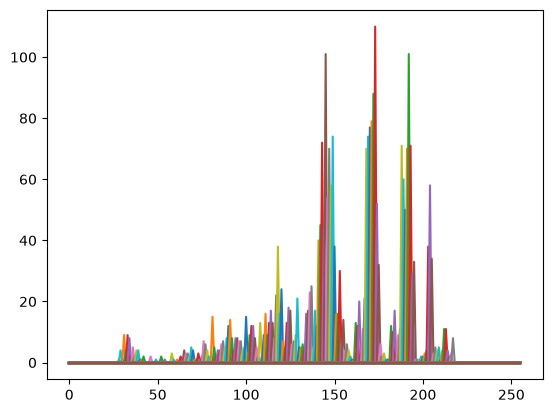

In [108]:
img = cv2.imread('..\\fol\\desk.jpeg')
tes = cv2.calcHist(
    img,
    [1,1],
    None,
    [256,256],
    [0,256,0,256]
)
import matplotlib.pyplot as plt

plt.plot(tes)
# cv2.imshow('test',tes)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [88]:
cv2.destroyAllWindows()

In [123]:
import cv2
import numpy as np
# Load images
cap = cv2.VideoCapture(0)
ret,frame = cap.read()

x,y,w,h = cv2.selectROI('image2',frame)
img2 =cv2.cvtColor( frame[y:y+h,x:x+w],cv2.COLOR_BGR2GRAY)


sift = cv2.SIFT_create()
while True:
    ret,frame = cap.read()
    # Find the keypoints and descriptors with SIFT
    kp1,des1 = sift.detectAndCompute(frame,None)
    # Find the keypoints and descriptors with SIFT
    kp2,des2 = sift.detectAndCompute(img2,None)
    
    
    # FLANN parameters
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    # Create FLANN matcher
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    # Match descriptors
    matches = flann.knnMatch(des1,des2,k=2)
    # Ratio test as per Lowe's paper
    good = []
    for m,n in matches:
        if m.distance < 0.7*n.distance:
            good.append(m)


    img3 = cv2.drawMatches(frame, kp1, img2, kp2, matches, None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    cv2.imshow('Matches', img3)
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break
    
cap.release()
cv2.destroyAllWindows()

error: OpenCV(5.0.0) :-1: error: (-5:Bad argument) in function 'drawMatches'
> Overload resolution failed:
>  - Can't parse 'matches1to2'. Sequence item with index 0 has a wrong type
>  - drawMatches() missing required argument 'matchesThickness' (pos 7)
>  - Can't parse 'matches1to2'. Sequence item with index 0 has a wrong type
>  - drawMatches() missing required argument 'matchesThickness' (pos 7)


In [124]:
cap.release()
cv2.destroyAllWindows()

Let’s break down your query step-by-step. You are dealing with a classic, highly complex Computer Vision (CV) architecture problem. 

First, to address **"firstly what I meant to do"**: Your intent is to build a **parallelized, multi-stream computer vision pipeline**. You want to isolate three distinct, heavy computational tasks (Person Detection, Object Detection, Object Tracking) across three separate camera feeds, ensuring that a lag or heavy processing load in one task doesn't freeze the others, all while running strictly on a CPU.

Here is the comprehensive guide to achieving this, the hardware realities, and the multiprocessing vs. multithreading debate.

---

### 1. Threads vs. Processes: Pros and Cons for this Scenario
Before writing code, you must choose your concurrency model. Because you are doing heavy math (CV and Deep Learning), the **Python Global Interpreter Lock (GIL)** is your biggest enemy.

#### **Option A: Multithreading (Using `threading`)**
Threads share the same memory space and are subject to the GIL.
*   **Pros:** 
    *   **Zero IPC (Inter-Process Communication) overhead:** All threads share the same RAM. Passing a 1080p frame from a camera thread to a detection thread takes almost zero time.
    *   **Low Memory Footprint:** You only load your AI models into RAM *once*.
*   **Cons:** 
    *   **The GIL Bottleneck:** If your AI framework (like standard PyTorch or TensorFlow on CPU) does not explicitly release the GIL during inference, your three "parallel" threads will actually execute **one after the other** on a single CPU core. Your frame rate will tank.
    *   *Exception:* If you use **OpenVINO** or **ONNX Runtime** for CPU inference, they *do* release the GIL, making multithreading highly efficient.

#### **Option B: Multiprocessing (Using `multiprocessing`)**
Processes have their own memory space and their own Python interpreter, completely bypassing the GIL.
*   **Pros:** 
    *   **True Parallelism:** Camera 1, 2, and 3 will run on separate CPU cores simultaneously, regardless of the GIL.
*   **Cons:** 
    *   **High Memory Usage:** Each process must load its own copy of the AI model weights into RAM.
    *   **IPC Overhead:** Passing large images (NumPy arrays) between processes using standard `multiprocessing.Queue` requires "pickling" (serializing) the data. This is incredibly slow and will destroy your frame rate.

**Verdict for your scenario:** Use **Multiprocessing** if you are using standard PyTorch/TensorFlow on CPU. Use **Multithreading** *only* if you convert your models to OpenVINO/ONNX format, which handles CPU threading natively and efficiently.

---

### 2. How to use Multiprocessing with OpenCV (The Right Way)
If you use standard `multiprocessing.Queue` to pass frames between a "Camera Reader Process" and a "Detection Process," **it will fail** because pickling a 1920x1080x3 image takes too long. 

**The Efficient Architecture:**
Do not separate the camera reading from the processing. Give each process its own camera feed and its own task.

```python
import cv2
import multiprocessing as mp
import time

# Task 1: Person Detection
def camera_1_pipeline(cam_id):
    cap = cv2.VideoCapture(cam_id)
    # Load your Person Detection model HERE (inside the process)
    while True:
        ret, frame = cap.read()
        if not ret: break
        
        # Resize frame to save CPU (e.g., to 640x480)
        frame = cv2.resize(frame, (640, 480)) 
        
        # Run Person Detection Model
        # results = person_model.predict(frame)
        
        # Draw boxes and optionally send small metadata to main process via Queue
        cv2.imshow("Cam 1 - Person Detection", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'): break
    cap.release()

# Task 2: Object Detection
def camera_2_pipeline(cam_id):
    cap = cv2.VideoCapture(cam_id)
    # Load Object Detection Model HERE
    while True:
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.resize(frame, (640, 480))
        # Run Object Detection
        cv2.imshow("Cam 2 - Object Detection", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'): break
    cap.release()

# Task 3: Object Tracking
def camera_3_pipeline(cam_id):
    cap = cv2.VideoCapture(cam_id)
    # Initialize Tracker (e.g., DeepSORT, ByteTrack) HERE
    while True:
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.resize(frame, (640, 480))
        # Run Tracking
        cv2.imshow("Cam 3 - Tracking", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'): break
    cap.release()

if __name__ == "__main__":
    # Start 3 independent processes
    p1 = mp.Process(target=camera_1_pipeline, args=(0,))
    p2 = mp.Process(target=camera_2_pipeline, args=(1,))
    p3 = mp.Process(target=camera_3_pipeline, args=(2,))

    p1.start()
    p2.start()
    p3.start()

    p1.join()
    p2.join()
    p3.join()
```
*Note: If you absolutely must share frames between processes, you must use Python 3.8+ `multiprocessing.shared_memory` to pass raw byte buffers without pickling.*

---

### 3. The Role of Hardware & Why Multiprocessing Might Fail
You asked: *"What is the role of hardware and how/why I can't do multiprocessing on it?"*

Hardware is the physical limit of your logic. Here is why your multiprocessing setup might crash or lag:

1.  **CPU Core Starvation (Context Switching):** 
    *   If you have a 4-core CPU, and you run 3 heavy multiprocessing tasks, plus the OS, plus the display rendering (`cv2.imshow`), your CPU is at 100% capacity. The OS will constantly pause and resume processes (context switching), which actually makes the system *slower* than running them sequentially.
    *   *Rule of thumb:* You need at least 1 CPU core per camera pipeline, plus 1 or 2 cores reserved for the OS and display.
2.  **Memory Bandwidth Bottleneck:** 
    *   CPUs process data by pulling it from RAM into L1/L2/L3 caches. Three cameras feeding 1080p frames simultaneously will saturate your RAM bandwidth. The CPU will spend more time waiting for image data to arrive from RAM than actually doing math.
3.  **The Lack of a GPU (The Elephant in the Room):**
    *   Deep learning (Detection/Tracking) is essentially massive matrix multiplication. CPUs are terrible at this; they have a few fast cores. GPUs have thousands of slow cores designed exactly for this. Running 3 detection models on a CPU will yield maybe 2-5 FPS per camera. On a GPU, it would be 60+ FPS.

---

### 4. How it Affects RAM/Memory and How to be Efficient
**The RAM Impact:**
If you use Multiprocessing, and your YOLO model is 50MB, and you run 3 processes, you just used 150MB of RAM just for model weights, plus the Python environment overhead for each process. If you use heavy models, you could easily run out of RAM.

**How to use RAM and CPU efficiently:**
1.  **Downscale the Frames:** Never run detection on 1080p or 4K frames on a CPU. Use `cv2.resize()` to drop the frame to 416x416 or 640x640 *before* passing it to the AI model. This reduces CPU load and RAM bandwidth usage by 70%.
2.  **Use CPU-Optimized Models:** Do not use standard YOLOv8 or ResNet. Export your models to **ONNX** or **OpenVINO** format. OpenVINO is specifically optimized by Intel to run AI on CPUs using instructions like AVX2/AVX-512.
3.  **Use Shared Memory for Metadata:** If Process 1 (Person Detection) needs to send data to Process 3 (Tracker), do not send the image. Send a tiny JSON or array of bounding box coordinates via a `multiprocessing.Queue`.
4.  **Batching (If using a single process for multiple cameras):** If you realize multiprocessing is too heavy on RAM, switch to a single process, read all 3 cameras, stack the images into a single batch (e.g., a 3x640x640 array), and pass it through the model *once*. This is vastly more CPU/RAM efficient.

### Summary Recommendation for your Scenario
If you are strictly limited to a **CPU**:
1.  Do **not** use standard PyTorch/TensorFlow. Export your models to **OpenVINO**.
2.  Because OpenVINO handles CPU threading internally and releases the GIL, you can actually use **Multithreading** instead of Multiprocessing. This will save you massive amounts of RAM and avoid IPC bottlenecks.
3.  If you *must* use Multiprocessing, ensure your CPU has at least 6 to 8 physical cores, resize all camera feeds to 640p or lower, and ensure each process loads a lightweight model (like YOLO-Nano or MobileNet).